
# Lithium atomic beam: transverse cooling + optional 2D MOT + downstream orifice optimization

This notebook adds:

**(i)** Side-view schematic plots (x vs z) with representative trajectories for three cases:
1. No cooling, no 2D MOT
2. Transverse cooling in mirror region only
3. Transverse cooling + optimized 2D MOT

**(ii)** Prints the **optimized 2D MOT parameters** and the achieved gain in flux through the downstream orifice.


In [1]:
# Enable automatic reloading of modules so that changes in external Python files are reflected without restarting the notebook
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors
from dataclasses import dataclass, replace
from scipy.constants import k as k_B, h, c, atomic_mass
from scipy.special import erf
from scipy.optimize import minimize
from scipy.spatial.distance import cdist
import li6_cooling_opt_functions as cool
import ipywidgets as widgets
import warnings
from skopt import gp_minimize
from skopt.space import Real
from functools import partial

rng = np.random.default_rng(12345)

# ---------------- Physical constants ----------------
h = 6.62607015e-34
hbar = h/(2*np.pi)
kB = 1.380649e-23
amu = 1.66053906660e-27

print("Imports and constants loaded.")

Imports and constants loaded.


In [3]:
# cfg = cool.SourceConfig(tube_length=0.1, tube_radius=0.007/2)
cfg = cool.SourceConfig()
print(f"SourceConfig created: {cfg}")

SourceConfig created: SourceConfig(N_atoms=5000000, isotope='Li-6', mass=9.988142485598999e-27, lambda0=6.70977e-07, k=9364233.50901683, Gamma=36882297.753144175, Isat_mW_cm2=2.54, Isat=25.4, T_oven_C=600.0, T_oven_K=873.15, oven_channel_radius=0.02, tube_length=0.09453, tube_radius=0.001808, beta_mot=0.0, kappa_mot=0.0, B_grad=0.0, mu_eff=9.274e-24, Px_mW_mot=80.0, Py_mW_mot=80.0, w_mm_mot=6.0, N_bounce_x=6, N_bounce_y=6, Rpass_x=0.9, Rpass_y=0.9, Px_mW=80.0, Py_mW=80.0, w_mm=6.0, delta_over_Gamma=-1.0, z_cooling_start=0.02, z_cooling_end=0.22, z_mot_start=0.221, z_mot_end=0.28, z_orifice=3.0, orifice_radius=0.005, use_skimmer=False, skimmer_radius=0.005, dt=2e-06, include_diffusion=True, include_mot_diffusion=True, alpha_diff=0.5)


## Effusive flux estimate

In [4]:
Ndot_hole, P_oven, n_oven, vbar, A_hole = cool.effusive_flux_atoms_per_s(cfg.T_oven_K, cfg.mass, cfg.oven_channel_radius*2)
print(f"Vapor pressure ~ {P_oven:.3g} Pa, mean speed ~ {vbar:.1f} m/s")
print(f"Flux through the oven channel (prior to tube exit) ~ {Ndot_hole:.3e} atoms/s")

Vapor pressure ~ 6.59 Pa, mean speed ~ 1753.1 m/s
Flux through the oven channel (prior to tube exit) ~ 3.011e+20 atoms/s


## Simulate the Oven Source

Here, we simulate the oven source with the long tube exit geometry using an identical function as the oven optimization notebook. Here, we have added a calculation for the oven consumption given an estimated recycling efficiency of the stainless steel mesh.

In [5]:
# This creates the distribution of atoms exiting the tube, including their positions and velocities, to use in the cooling and MOT sims
beam_exiting_tube = cool.sample_effusive_beam(cfg)
print("Sampled atoms:", len(beam_exiting_tube["x"]))
print("Transmission frequency:", len(beam_exiting_tube["x"])/cfg.N_atoms * 100, "%")
print("Mean vz:", beam_exiting_tube["vz"].mean())
print("Mean transverse speed:", np.sqrt(beam_exiting_tube["vx"]**2 + beam_exiting_tube["vy"]**2).mean())

# Calculate the oven consumption
consumption_rates = cool.oven_consumption_rate(beam_exiting_tube, cfg, recycling_efficiency=0.8)
print(f"Oven consumption rate: {consumption_rates['consumption_rate_grams_per_day']:.3e} grams/day")
print(f"Oven consumption rate: {consumption_rates['consumption_rate_grams_per_hour']:.3e} grams/hour")
print(f"Oven consumption rate: {consumption_rates['consumption_rate_grams_per_year']:.3e} grams/year")

# recycling_efficiencies = np.linspace(0, 1, 11)
# cool.plot_consumptions(beam_exiting_tube, cfg, recycling_efficiencies=recycling_efficiencies)

Sampled atoms: 1833
Transmission frequency: 0.036660000000000005 %
Mean vz: 2064.6409642577087
Mean transverse speed: 35.486407756860096
Oven consumption rate: 4.253e-01 grams/day
Oven consumption rate: 1.772e-02 grams/hour
Oven consumption rate: 1.553e+02 grams/year


## 2D MOT Optimization

In this section, we use three different methods of optimizing the 2D MOT region:

1)  Using a damped harmonic oscillator model and looping through various parameters defined by the user
2)  Using the MOT force as defined in "Laser Cooling and Trapping" by Metcalf and van der Straten, **11.4a** and **11.4b**, but still looping through user defined parameters. In this section, we find optimal B field gradient in addition to MOT length.
3)  Using the MOT force, but now implementing the machine learning package from SciKit used in the oven optimization

For all models, the parameter that is being optimized is the flux throught the downstream orifice located at **3 m**.

### Damped Harmonic Oscillator model

In [6]:
df_scan, best = cool.optimize_2dmot_with_beam(beam_exiting_tube, cfg)
best

{'L_mot_cm': 15.0,
 'beta': 5e-23,
 'kappa': 2e-19,
 'frac_pass': np.float64(0.41189307146753956),
 'Ndot_orifice': np.float64(755.0),
 'orifice_flux': np.float64(371533384783357.3)}

In [7]:
df_scan.sort_values("Ndot_orifice", ascending=False).head(10)

,L_mot_cm,beta,kappa,frac_pass,Ndot_orifice,orifice_flux
247,15.0,5.000000e-23,2.000000e-19,0.411893,755.0,3.715334e+14
175,10.0,5.000000e-23,2.000000e-19,0.385161,706.0,3.474206e+14
211,12.5,5.000000e-23,2.000000e-19,0.382433,701.0,3.449601e+14
246,15.0,5.000000e-23,0.000000e+00,0.372068,682.0,3.356103e+14
210,12.5,5.000000e-23,0.000000e+00,0.353519,648.0,3.188790e+14
139,7.5,5.000000e-23,2.000000e-19,0.333879,612.0,3.011635e+14
241,15.0,2.000000e-23,2.000000e-19,0.321877,590.0,2.903373e+14
205,12.5,2.000000e-23,2.000000e-19,0.318603,584.0,2.873848e+14
103,5.0,5.000000e-23,2.000000e-19,0.311511,571.0,2.809875e+14
169,10.0,2.000000e-23,2.000000e-19,0.301146,552.0,2.716377e+14


#### Plotting Sideviews

Here, we run three cases and plot side-view trajectories, comparing beam profiles with and without both the tranverse cooling and the 2D MOT regions.

In [8]:
# --- run the three configurations ---
n_traj = 200

# Case 1: no cooling, no 2D MOT
case1 = cool.propagate_system_with_beam(
    beam=beam_exiting_tube,
    cfg=replace(cfg, beta_mot=0.0, kappa_mot=0.0),
    use_mot=False,
    mirror_cooling=False,
    record_traj=True,
    n_traj=n_traj,
    n_record_region=6,
    orifice_reference="3 meters from tube exit"
)

# Case 2: mirror cooling only, no 2D MOT
case2 = cool.propagate_system_with_beam(
    beam=beam_exiting_tube,
    cfg=replace(cfg, beta_mot=0.0, kappa_mot=0.0),
    use_mot=False,
    mirror_cooling=True,
    record_traj=True,
    n_traj=n_traj,
    n_record_region=6,
    orifice_reference="3 meters from tube exit"
)

# Case 3: mirror cooling + 2D MOT
case3 = cool.propagate_system_with_beam(
    beam=beam_exiting_tube,
    cfg=replace(cfg, beta_mot=best["beta"], kappa_mot=best["kappa"]),
    use_mot=True,
    mirror_cooling=True,
    record_traj=True,
    n_traj=n_traj,
    n_record_region=6,
    orifice_reference="3 meters from tube exit"
)

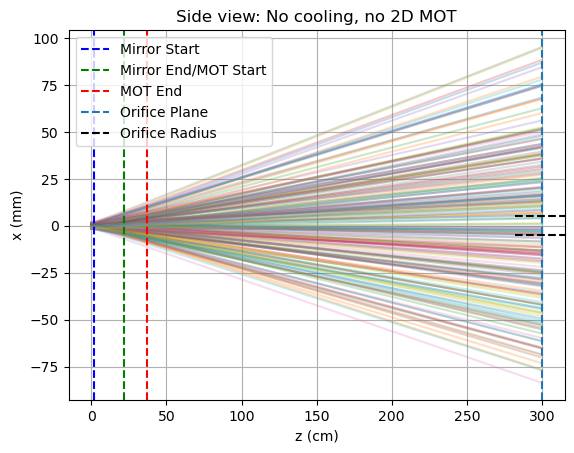

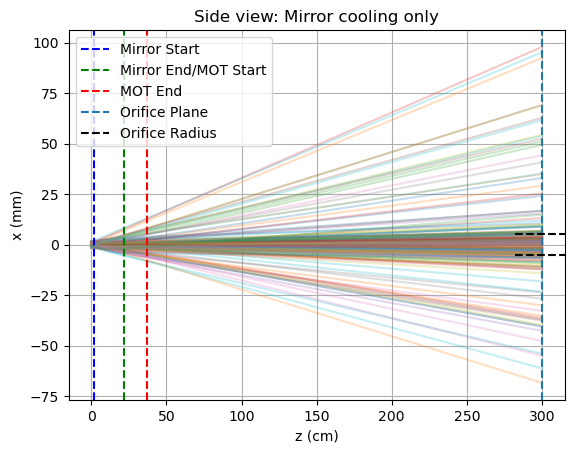

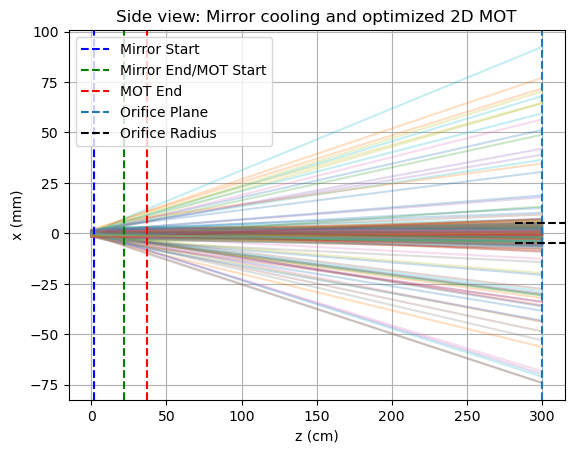

In [23]:
cases = ["No cooling, no 2D MOT", "Mirror cooling only", "Mirror cooling and optimized 2D MOT"]
for i in range(3):
    cool.plot_sideview(eval(f"case{i+1}"), cfg, 15.0, f"Side view: {cases[i]}")


### 2D MOT Force Model with User Loop

In [10]:
df_scan_full, best_full = cool.optimize_full_2dmot_with_beam(beam_exiting_tube, cfg)
best_full

{'L_mot_cm': 15.0,
 'B_grad': 0.07,
 'frac_pass': np.float64(0.6633933442444081),
 'Ndot_orifice': np.float64(1216.0),
 'orifice_flux': np.float64(598390193240480.1)}

In [11]:
df_scan_full.sort_values("Ndot_orifice", ascending=False).head(10)

,L_mot_cm,B_grad,frac_pass,Ndot_orifice,orifice_flux
45,15.0,0.07,0.663393,1216.0,5.983902e+14
43,15.0,0.03,0.662302,1214.0,5.974060e+14
37,12.5,0.05,0.657938,1206.0,5.934692e+14
44,15.0,0.05,0.656301,1203.0,5.919929e+14
36,12.5,0.03,0.655210,1201.0,5.910087e+14
29,10.0,0.03,0.650300,1192.0,5.865799e+14
38,12.5,0.07,0.648663,1189.0,5.851036e+14
30,10.0,0.05,0.643208,1179.0,5.801826e+14
31,10.0,0.07,0.643208,1179.0,5.801826e+14
39,12.5,0.10,0.637207,1168.0,5.747695e+14


#### Plotting Sideviews

In [12]:
# --- run the three configurations ---
n_traj = 200

# Case 1: no cooling, no 2D MOT
case1_full = cool.propagate_system_with_beam(
    beam=beam_exiting_tube,
    cfg=replace(cfg),
    use_mot=False,
    mirror_cooling=False,
    record_traj=True,
    n_traj=n_traj,
    n_record_region=6,
    orifice_reference="3 meters from tube exit"
)

# Case 2: mirror cooling only, no 2D MOT
case2_full = cool.propagate_system_with_beam(
    beam=beam_exiting_tube,
    cfg=replace(cfg),
    use_mot=False,
    mirror_cooling=True,
    record_traj=True,
    n_traj=n_traj,
    n_record_region=6,
    orifice_reference="3 meters from tube exit"
)

# Case 3: mirror cooling + 2D MOT
case3_full = cool.propagate_system_with_beam(
    beam=beam_exiting_tube,
    cfg=replace(cfg, z_mot_end = cfg.z_mot_start + best_full["L_mot_cm"]*1e-2, B_grad=best_full["B_grad"]),
    use_mot=True,
    mirror_cooling=True,
    mot_mode='mot_full',
    record_traj=True,
    n_traj=n_traj,
    n_record_region=6,
    orifice_reference="3 meters from tube exit"
)

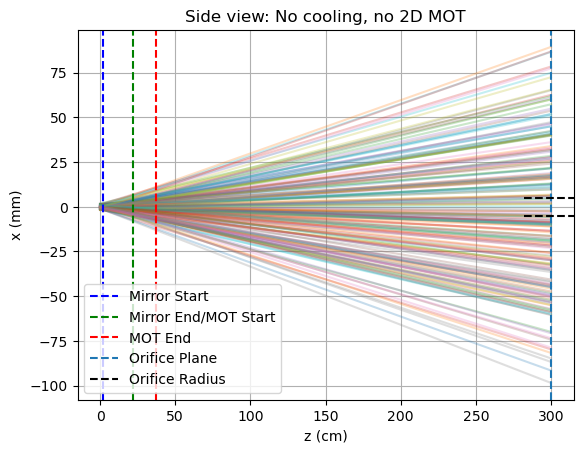

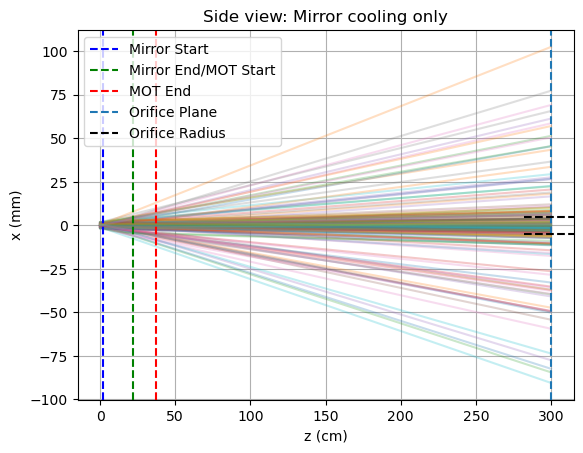

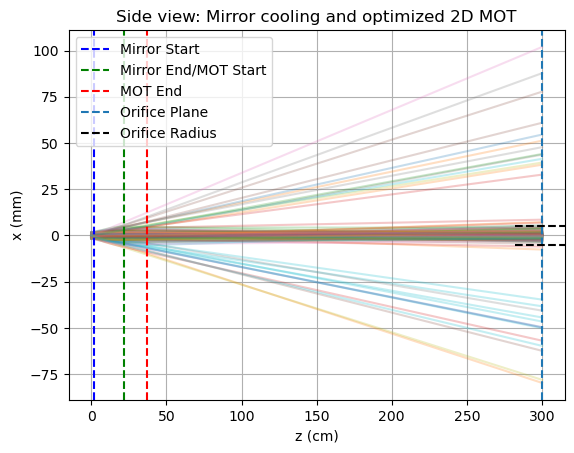

In [25]:
cases = ["No cooling, no 2D MOT", "Mirror cooling only", "Mirror cooling and optimized 2D MOT"]
for i in range(3):
    cool.plot_sideview(eval(f"case{i+1}_full"), cfg, 15.0, f"Side view: {cases[i]}")

### 2D MOT Force with Machine Learning Optimization

In addition to finding the optimal B field gradient and MOT length, now we find optimums for laser powers and widths.

In [14]:
mot_search_space = [
    Real(1.0, 15.0, name='mot_length_cm'),
    Real(0.01, 0.2, name='B_grad'),
    Real(40.0, 120.0, name='Px_mw'),
    Real(40.0, 120.0, name='Py_mw'),
    Real(3.0, 9.0, name='w_mm')
]

cfg_local = replace(cfg)

objective = partial(
    cool.objective,
    beam=beam_exiting_tube,
    cfg_base=cfg_local,
)

with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=RuntimeWarning)
    warnings.filterwarnings("ignore", message=".*ConvergenceWarning.*")
    with np.errstate(all="ignore"):
        res = gp_minimize(
            objective,
            dimensions=mot_search_space,
            acq_func='EI',
            n_calls=100,
            random_state=42
        )

best_length_cm, best_grad, best_Px_mw, best_Py_mw, best_w_mm = res.x
best_flux = res.fun

c:\Users\dusty\miniconda3\envs\Li6Beam\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [15.0, 0.01, 40.0, 40.0, 9.0] before, using random point [2.531892126572358, 0.10816704658687959, 96.80795136258438, 44.49620757824868, 4.586102646893416]
  warnings.warn(
c:\Users\dusty\miniconda3\envs\Li6Beam\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [15.0, 0.01, 40.0, 40.0, 9.0] before, using random point [9.45237337753878, 0.10444964731380274, 49.1882417950831, 93.48363281647123, 6.8242410215408125]
  warnings.warn(
c:\Users\dusty\miniconda3\envs\Li6Beam\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [15.0, 0.01, 40.0, 40.0, 9.0] before, using random point [11.492090371484787, 0.07858552016784932, 61.0898412565799, 78.818755629855, 8.826617261358734]
  warnings.warn(
c:\Users\dusty\miniconda3\envs\Li6Beam\Lib\site-p

In [15]:
print(f"Best parameters: L_mot={best_length_cm:.2f} cm, "
      f"B_grad={best_grad:.3f} T/m, "
      f"Px_mw={best_Px_mw:.1f} mW, "
      f"Py_mw={best_Py_mw:.1f} mW, "
      f"w_mm={best_w_mm:.2f} mm")

print(f"Best flux at orifice: {-best_flux:.3e} atoms/s")

Best parameters: L_mot=15.00 cm, B_grad=0.046 T/m, Px_mw=40.0 mW, Py_mw=40.0 mW, w_mm=9.00 mm
Best flux at orifice: 6.323e+14 atoms/s


For this full optimized case, the transverse velocity is 11.366951426545748.


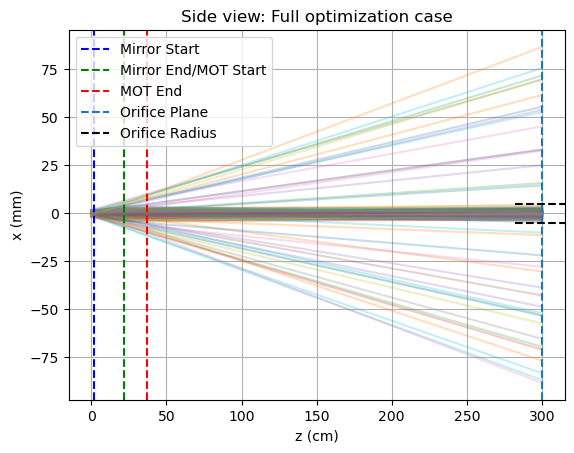

In [29]:
# Rerunning to optimized parameters
n_traj = 200

full_opt_case = cool.propagate_system_with_beam(
    beam=beam_exiting_tube,
    cfg=replace(cfg, z_mot_end = cfg.z_mot_start + best_length_cm*1e-2, B_grad=best_grad,
        Px_mW_mot=best_Px_mw, Py_mW_mot=best_Py_mw),
    use_mot=True,
    mirror_cooling=True,
    mot_mode='mot_full',
    record_traj=True,
    n_traj=n_traj,
    n_record_region=6,
    orifice_reference="3 meters from tube exit"
)

# Print transverse velocity of atoms exiting the MOT region
print(f"For this full optimized case, the transverse velocity is {full_opt_case['transverse_velocity']}.")

cool.plot_sideview(full_opt_case, cfg, 15.0, "Side view: Full optimization case")